In [29]:
from typing import Callable
import re
import pandas as pd
import numpy as np
from dateutil.parser import parse
import matplotlib as mpl
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
mpl.style.use('dark_background')

In [30]:
def get_pattern(args: list[str]):
    pattern_builder = r"\[(?P<timestamp>.*?)\] "
    [*head, tail] = args
    for arg in head:
        pattern_builder += f"{arg}: (?P<{arg}>.*?), "
    pattern_builder += f"{tail}: (?P<{tail}>.*)"
    return re.compile(pattern_builder)

def create_df(results: list[dict], argdict: dict[str, Callable]) -> pd.DataFrame:
    if "timestamp" not in argdict:
        argdict["timestamp"] = lambda t: parse(t, fuzzy=True)
    df = pd.DataFrame(results)
    for key, mapfn in argdict.items():
        df[key] = df[key].map(mapfn)
    return df

def corr(df: pd.DataFrame, f1: str, f2: str) -> float:
    corr = df.corr().loc[f1, f2]
    if pd.isna(corr):
        return .0
    return corr

def autocorr(df: pd.DataFrame, f: str) -> float:
    return corr(df, "timestamp", f)

In [31]:
train_keys = {
    "kl": float,
    "lrMultiplier": float,
    "loss": float,
    "entropy": float,
    "explVarOld": float,
    "explVarNew": float,
}

eval_keys = {
    "numPlayouts": int,
    "win": int,
    "lose": int,
    "tie": int,
    "avgCurrStarted": float,
}

In [32]:
train_pattern = get_pattern(train_keys)
eval_pattern = get_pattern(eval_keys)

train_results, eval_results = [], []
with open("_zero/logs/losses.log", "r") as f:
    for line in f.readlines():
        assert line != "", "Empty line"
        train_match = train_pattern.search(line)
        if train_match is not None:
            train_results += [train_match.groupdict()]
        eval_match = eval_pattern.search(line)
        if eval_match is not None:
            eval_results += [eval_match.groupdict()]

train_df = create_df(train_results, train_keys)
eval_df = create_df(eval_results, eval_keys)

In [33]:
train_df.describe()

,timestamp,kl,lrMultiplier,loss,entropy,explVarOld,explVarNew
count,3519,3519.000000,3519.000000,3519.000000,3519.000000,3519.000000,3519.000000
mean,2024-01-02 03:33:45.055285248,0.034713,0.092110,2.062615,1.437626,0.211916,0.229072
min,2023-12-30 17:12:39.558000,0.006370,0.088000,1.213490,0.795080,-0.078000,-0.026000
25%,2024-01-01 04:21:40.511500032,0.022310,0.088000,1.793715,1.210140,0.120000,0.132000
50%,2024-01-02 13:03:52.822000128,0.030420,0.088000,2.000780,1.344580,0.221000,0.243000
75%,2024-01-03 02:34:09.565500160,0.042030,0.088000,2.228175,1.556765,0.294000,0.315000
max,2024-01-03 15:22:19.593000,0.127900,0.667000,5.098120,4.124200,0.529000,0.578000
std,NaN,0.017699,0.030493,0.453430,0.414302,0.117212,0.122949


In [34]:
train_df.corr().style.background_gradient("hot")

,timestamp,kl,lrMultiplier,loss,entropy,explVarOld,explVarNew
timestamp,1.000000,-0.169199,-0.243938,-0.391248,-0.362013,0.709715,0.742533
kl,-0.169199,1.000000,-0.000657,0.043617,0.036915,-0.148899,-0.154185
lrMultiplier,-0.243938,-0.000657,1.000000,0.635794,0.631553,-0.210658,-0.214560
loss,-0.391248,0.043617,0.635794,1.000000,0.958773,-0.484234,-0.481645
entropy,-0.362013,0.036915,0.631553,0.958773,1.000000,-0.374196,-0.373492
explVarOld,0.709715,-0.148899,-0.210658,-0.484234,-0.374196,1.000000,0.996285
explVarNew,0.742533,-0.154185,-0.214560,-0.481645,-0.373492,0.996285,1.000000


In [35]:
eval_df.describe()

,timestamp,numPlayouts,win,lose,tie,avgCurrStarted
count,70,70.000000,70.000000,70.000000,70.0,70.000000
mean,2024-01-02 04:32:38.437757184,1485.714286,2.242857,7.757143,0.0,0.511429
min,2023-12-30 17:23:42.671000,1000.000000,0.000000,2.000000,0.0,0.200000
25%,2024-01-01 06:03:42.934000128,1500.000000,1.000000,7.000000,0.0,0.400000
50%,2024-01-02 13:43:14.885499904,1500.000000,2.000000,8.000000,0.0,0.500000
75%,2024-01-03 02:52:16.886749952,1500.000000,3.000000,9.000000,0.0,0.600000
max,2024-01-03 15:29:12.873000,1500.000000,8.000000,10.000000,0.0,0.800000
std,NaN,83.900760,2.108889,2.108889,0.0,0.154679


In [36]:
eval_df.corr().style.background_gradient("hot")

/opt/homebrew/lib/python3.11/site-packages/pandas/io/formats/style.py:3819: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/opt/homebrew/lib/python3.11/site-packages/pandas/io/formats/style.py:3820: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,timestamp,numPlayouts,win,lose,tie,avgCurrStarted
timestamp,1.000000,0.392279,0.655222,-0.655222,nan,0.026131
numPlayouts,0.392279,1.000000,0.142756,-0.142756,nan,0.012763
win,0.655222,0.142756,1.000000,-1.000000,nan,0.053569
lose,-0.655222,-0.142756,-1.000000,1.000000,nan,-0.053569
tie,nan,nan,nan,nan,nan,nan
avgCurrStarted,0.026131,0.012763,0.053569,-0.053569,nan,1.000000


In [37]:
# Fairness of Evaluation

round_fairness_significance = .05
n_evaluation_games = 10

n_total_games = len(eval_df) * n_evaluation_games
mean_total_games = int(round(eval_df['avgCurrStarted'].mean() * n_total_games))
std_total_games = int(round(eval_df['avgCurrStarted'].std() * n_total_games))

round_fairness = eval_df["avgCurrStarted"].mean() - .5
round_fairness_autocorr = autocorr(eval_df, "avgCurrStarted")

round_fairness_doubt = False

print(f"[Info] The first player is said to have an unfair advantage in the game, so it should be checked that the number of plays were indeed balanced.")
print(f"[Info] {n_total_games} games played in total, distributed as: [{mean_total_games} - z * {std_total_games}, {mean_total_games} + z * {std_total_games}]")

if abs(round_fairness) > round_fairness_significance:
    round_fairness_doubt = True
    if round_fairness > .0:
        print(f"[Warn] The number of plays which the CURRENT player started is above the significance: {round_fairness:.4f} > {round_fairness_significance}")
    else:
        print(f"[Warn] The number of plays which the OPPONENT player started is above the significance: {-round_fairness:.4f} > {round_fairness_significance}")

if abs(round_fairness_autocorr) > round_fairness_significance:
    round_fairness_doubt = True
    if round_fairness_autocorr > .0:
        print(f"[Warn] The number of plays which the CURRENT player started tend to increase significantly: {round_fairness_autocorr:.4f} > {round_fairness_significance}")
    else:
        print(f"[Warn] The number of plays which the OPPONENT player started tend to increase significantly: {-round_fairness_autocorr:.4f} > {round_fairness_significance}")

if round_fairness_doubt:
    print(f"[Warn] If there is a doubt, you can relax the evaluation results in favour of the disadvantaged player.")

[Info] The first player is said to have an unfair advantage in the game, so it should be checked that the number of plays were indeed balanced.
[Info] 700 games played in total, distributed as: [358 - z * 108, 358 + z * 108]


[Warn] The current model tends not to improve over time, as indicated by the auto-correlation value: 0.6670 < 0.7
[Warn] Either the evaluation step is too harsh for the current model, or the model does not learn


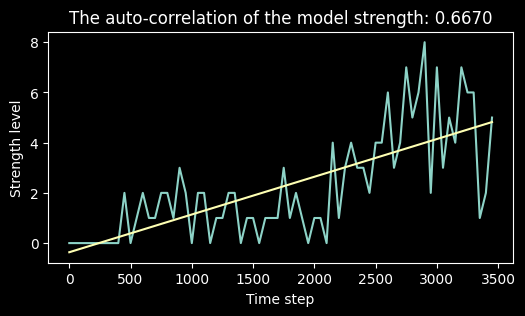

In [38]:
# Difficulty Estimation

eval_checkpoint = 50
num_wins = 10
num_playouts = 1500

eval_df["batch"] = eval_df.index * eval_checkpoint
eval_df.set_index("batch", inplace=True)

eval_df["strength"] = (eval_df["win"] + eval_df["tie"] / 2 + (eval_df["numPlayouts"] / num_playouts  - 1) * num_wins).round(2)
eval_df["strength"] = eval_df["strength"].map(lambda x: 0 if x < 0 else x)

strength_significance = .7

strength_corr = autocorr(eval_df, "strength")
if strength_corr < strength_significance:
    print(f"[Warn] The current model tends not to improve over time, as indicated by the auto-correlation value: {strength_corr:.4f} < {strength_significance}")
    print(f"[Warn] Either the evaluation step is too harsh for the current model, or the model does not learn")

x_axis = eval_df.index.values.reshape(-1, 1)

strength_lr = LinearRegression()
strength_lr.fit(x_axis, eval_df["strength"].values)

strength_estimator = lambda x: strength_lr.coef_ * x + strength_lr.intercept_

fig, axes = plt.subplots(1, 1, figsize=(6, 3))

axes = eval_df["strength"].plot(ax=axes)
axes.set_title(f"The auto-correlation of the model strength: {strength_corr:.4f}")
axes.plot(x_axis, list(map(strength_estimator, x_axis)))
axes.set_xlabel('Time step')
axes.set_ylabel('Strength level')

plt.show()

[Info] Loss: Sum of policy loss and value loss, the main objective function to be minimized during training
[Warn] The loss does not decrease significantly, which prevents the convergence of the model: -0.3912 > -0.5
[Warn] There might be a problem in loss function or hyperparameters


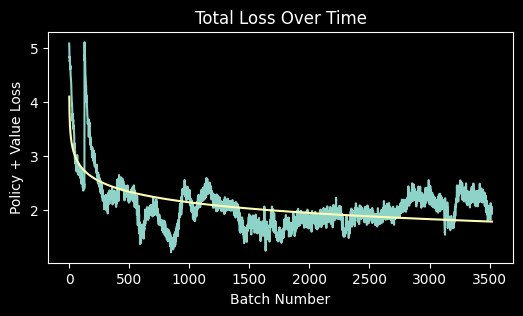

In [43]:
# Loss and Learning Rate

print(f"[Info] Loss: Sum of policy loss and value loss, the main objective function to be minimized during training")

loss_significance = -.5

loss_corr = autocorr(train_df, "loss")

if loss_corr > loss_significance:
    print(f"[Warn] The loss does not decrease significantly, which prevents the convergence of the model: {loss_corr:.4f} > {loss_significance}")
    print(f"[Warn] There might be a problem in loss function or hyperparameters")
    
x_axis = np.arange(len(train_df)).reshape(-1, 1) + 1
    
loss_lr = LinearRegression()
loss_lr.fit(np.log(x_axis), train_df["loss"])
loss_estimator = lambda x: loss_lr.coef_[0] * x + loss_lr.intercept_
    
fig, axes = plt.subplots(1, 1, figsize=(6, 3))
ax = train_df["loss"].plot(ax=axes)
ax.set_title("Total Loss Over Time")
ax.set_xlabel("Batch Number")
ax.set_ylabel("Policy + Value Loss")
ax.plot(x_axis, list(map(loss_estimator, np.log(x_axis))))

plt.show()

[Info] Entropy(probs): Measurement of how efficient the action prob. distribution is encoded
[Info] KL-Divergence(oldProbs, newProbs): Measurement of how much the new distribution differ from the old one
[Warn] Entropy seems to not decrease during training: -0.3620 > -0.5
[Warn] The learned action probabilities might be significantly imbalanced towards negative or positive


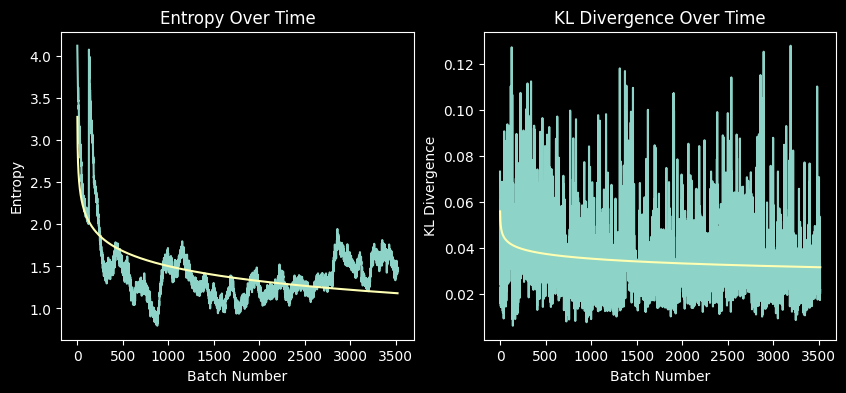

In [44]:
# Measuring Policy Estimation

print(f"[Info] Entropy(probs): Measurement of how efficient the action prob. distribution is encoded")
print(f"[Info] KL-Divergence(oldProbs, newProbs): Measurement of how much the new distribution differ from the old one")

entropy_significance = -.5
kl_significance = -0.01

entropy_corr = autocorr(train_df, "entropy")
kl_corr = autocorr(train_df, "kl")

if entropy_corr > entropy_significance:
    print(f"[Warn] Entropy seems to not decrease during training: {entropy_corr:.4f} > {entropy_significance}")
    print(f"[Warn] The learned action probabilities might be significantly imbalanced towards negative or positive")

if kl_corr > kl_significance:
    print(f"[Warn] KL Divergence does not decrease over time as much as expected: {kl_corr:.4f} > {kl_significance}")
    print(f"[Warn] The model might still need more training or there might be other destabilizing factors causing this issue")
    
x_axis = np.arange(len(train_df)).reshape(-1, 1) + 1

entropy_lr = LinearRegression()
entropy_lr.fit(np.log(x_axis), train_df["entropy"].values)
entropy_estimator = lambda x: entropy_lr.coef_[0] * x + entropy_lr.intercept_

kl_lr = LinearRegression()
kl_lr.fit(np.log(x_axis), train_df["kl"])
kl_estimator = lambda x: kl_lr.coef_[0] * x + kl_lr.intercept_

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax1 = train_df["entropy"].plot(ax=axes[0])
ax1.set_title("Entropy Over Time")
ax1.set_xlabel("Batch Number")
ax1.set_ylabel("Entropy")
ax1.plot(x_axis, list(map(entropy_estimator, np.log(x_axis))))

ax2 = train_df["kl"].plot(ax=axes[1])
ax2.set_title("KL Divergence Over Time")
ax2.set_xlabel("Batch Number")
ax2.set_ylabel("KL Divergence")
ax2.plot(x_axis, list(map(kl_estimator, np.log(x_axis))))

plt.show()

[Info] Explained-Variance(value): Measurement of how close the predicted value is to the actual reward


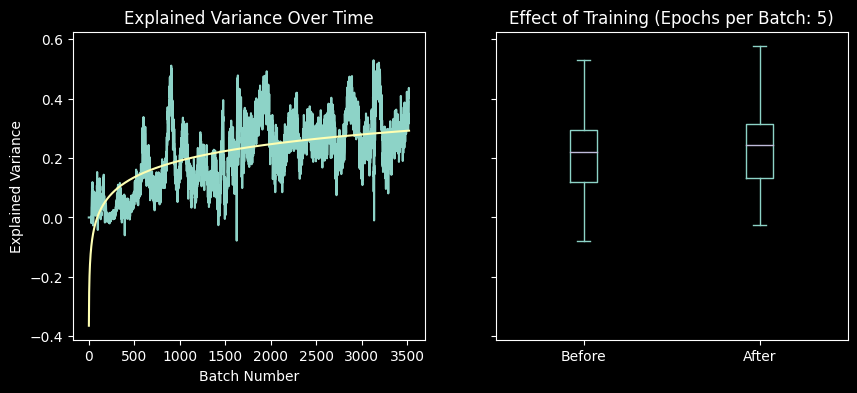

In [45]:
# Measuring Value Estimation

print(f"[Info] Explained-Variance(value): Measurement of how close the predicted value is to the actual reward")

expl_var_significance = .4
expl_var_difference_significance = .01

expl_var_corr = autocorr(train_df, "explVarOld")
if expl_var_corr < expl_var_significance:
    print(f"[Warn] The explained variance seems to not increase over time: {expl_var_corr:.4f} < {expl_var_significance}")
    print(f"[Warn] There might be an unknown learning issue which is probably caused by learning rate, loss function etc.")

expl_var_difference = (train_df["explVarNew"] - train_df["explVarOld"]).mean()
if expl_var_difference < expl_var_difference_significance:
    print(f"[Warn] The new explained variance tends not to differ significantly from the older one: {expl_var_difference:.4f} < {expl_var_difference_significance}")
    print(f"[Warn] Either the value loss is set correctly or the learning rate is too small")

n_epochs = 5

x_axis = np.arange(len(train_df)).reshape(-1, 1) + 1

expl_var_lr = LinearRegression()
expl_var_lr.fit(np.log(x_axis), train_df["explVarOld"].values)
expl_var_estimator = lambda x: expl_var_lr.coef_ * x + expl_var_lr.intercept_

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
ax1 = train_df["explVarOld"].plot(ax=axes[0])
ax1.set_title("Explained Variance Over Time")
ax1.set_xlabel("Batch Number")
ax1.set_ylabel("Explained Variance")
ax1.plot(x_axis, list(map(expl_var_estimator, np.log(x_axis))))

expl_var_difference_stats = train_df[["explVarOld", "explVarNew"]]
ax2 = expl_var_difference_stats.plot(kind="box", ax=axes[1])
ax2.set_title(f"Effect of Training (Epochs per Batch: {n_epochs})")
ax2.set_xticklabels(["Before", "After"])

plt.show()

/var/folders/gq/zf4jplr54kzc3vr7btq8ptc40000gp/T/ipykernel_2832/4207785269.py:32: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_axis, [0] * len(x_axis), 'k--', color="red")


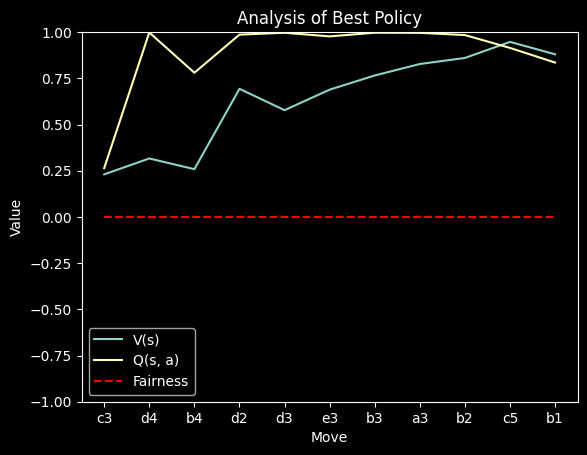

In [42]:
# Fairness of Game

from src import Gomoku, PolicyValueNet, UCT_Player, Pattern

Pi_s = "c3,d4,b4,d2,d3,e3,b3,a3,b2,c5,b1" # winning strategy for the first player

V_s = []
Q_sa = []

game_kwargs = {
    'M': 6,
    'N': 6,
    'K': 4,
}

game = Gomoku(**game_kwargs)
net = PolicyValueNet(game_kwargs=game_kwargs, model_file="_zero/models/curr_6_6_4.model")
net_player = UCT_Player(iterations=400, policy_value_fn=net.policy_value_fn_sorted, c_puct=5)

for move in Pattern.loc_to_move(Pi_s):
    probs, value = net.policy_value_fn_sorted(game)
    max_prob, max_action = max(probs)
    assert max_action == move, "The best policy is different from the given move"
    game.play(move)
    V_s += [value.detach().item()]
    Q_sa += [max_prob]
    
x_axis = Pi_s.split(",")
ax = plt.subplot(1, 1, 1)
ax.plot(x_axis, V_s)
ax.plot(x_axis, Q_sa)
ax.plot(x_axis, [0] * len(x_axis), 'k--', color="red")
ax.set_ylim(-1, 1)
ax.set_xlabel("Move")
ax.set_ylabel("Value")
ax.set_title("Analysis of Best Policy")
ax.legend(["V(s)", "Q(s, a)", "Fairness"])
plt.show()